# Conectividad en el Dominio de la Frecuencia — Redes de Desbordamiento de Baruník & Křehlík (2018)

**¿Se transmiten los choques macroeconómicos y financieros entre mercados principalmente a altas frecuencias (ruido de corto plazo) o a bajas frecuencias (tendencias estructurales de largo plazo)?** Diebold & Yilmaz (2012) fueron pioneros en redes de descomposición de varianza direccional para riesgo sistémico. Sin embargo, las medidas de desbordamiento de VAR en el dominio del tiempo agregan todos los horizontes de pronóstico. Baruník & Křehlík (2018, *Journal of Financial Econometrics*) introdujeron la **conectividad en el dominio de la frecuencia**, descomponiendo la descomposición generalizada de varianza del error de pronóstico (GFEVD) a través de frecuencias espectrales $\omega \in (-\pi, \pi)$. Este cuaderno ejecuta `puremacro.connectedness.bk2018.barunik_krehlik` para disecar las redes de desbordamiento de alta frecuencia vs baja frecuencia en un sistema macro-financiero.

## El método en matemáticas — GFEVD Descompuesta por Frecuencias

Considere un proceso VAR de $N$ variables $Y_t = \sum_{l=1}^p A_l Y_{t-l} + \varepsilon_t$ con covarianza residual $\Sigma$.

**Representación Espectral.** La función de respuesta en frecuencia es $\Psi(e^{-i\omega}) = \left(I - \sum_{l=1}^p A_l e^{-il\omega}\right)^{-1}$, dando la densidad espectral $S_Y(\omega) = \Psi(e^{-i\omega}) \Sigma \Psi'(e^{i\omega})$.

**GFEVD a la Frecuencia $\omega$.** La proporción de varianza en la variable $j$ debida al choque $k$ a la frecuencia $\omega$ es:
$$ \theta_{j,k}(\omega) = \frac{\sigma_{kk}^{-1} \left| \big(\Psi(e^{-i\omega})\Sigma\big)_{j,k} \right|^2}{\big(S_Y(\omega)\big)_{j,j}} $$
**Acumulación por Bandas de Frecuencia.** Integrando $\theta_{j,k}(\omega)$ sobre la banda de frecuencia $[\omega_a, \omega_b]$ se obtiene la matriz de desbordamiento específica de la frecuencia:
$$ C_{\text{TOTAL}}^{\text{banda}} = \frac{100}{N} \sum_{j \neq k} \tilde\theta_{j,k}^{\text{banda}} $$

## Configuración — estimando la conectividad de frecuencia

Generamos un sistema VAR macro-financiero de 4 variables (ej., Inflación, Brecha del Producto, Tasa de Interés, Volatilidad Financiera) y descomponemos los desbordamientos sobre la banda de frecuencia espectral $[\pi/4, \pi]$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.connectedness.bk2018 import barunik_krehlik

# Semilla para reproducibilidad
rng = np.random.default_rng(123)

T = 300
N = 4

# Simular sistema VAR(1) con dinámica diagonal fuerte y desbordamientos cruzados
A1 = np.array([
    [0.75, 0.12, 0.05, 0.02],
    [0.05, 0.80, 0.10, 0.03],
    [0.02, 0.15, 0.70, 0.18],
    [0.01, 0.04, 0.22, 0.65]
])

Sigma = np.array([
    [1.00, 0.25, 0.15, 0.10],
    [0.25, 1.20, 0.30, 0.12],
    [0.15, 0.30, 0.90, 0.35],
    [0.10, 0.12, 0.35, 1.50]
])

# Simular datos de series de tiempo
data = np.zeros((T, N))
L = np.linalg.cholesky(Sigma)

for t in range(1, T):
    data[t] = A1 @ data[t-1] + L @ rng.standard_normal(N)

# Calcular conectividad de frecuencia de Baruník & Křehlík sobre banda de alta frecuencia (pi/4 a pi)
res_high = barunik_krehlik(data, var_lags=1, freq_bounds=(np.pi / 4.0, np.pi))
# Calcular conectividad de frecuencia de Baruník & Křehlík sobre banda de baja frecuencia (0 a pi/4)
res_low = barunik_krehlik(data, var_lags=1, freq_bounds=(0.0, np.pi / 4.0))

total_high = res_high["total_spillover"]
total_low = res_low["total_spillover"]
band_mat_high = res_high["band_matrix"]
band_mat_low = res_low["band_matrix"]

print(f"Índice de Desbordamiento Banda Alta Frecuencia (pi/4 a pi): {total_high:.2f}%")
print(f"Índice de Desbordamiento Banda Baja Frecuencia (0 a pi/4): {total_low:.2f}%")

# Afirmaciones clave
assert total_high > 0.0, "El índice de conectividad de alta frecuencia debe ser positivo"
assert total_low > 0.0, "El índice de conectividad de baja frecuencia debe ser positivo"
assert band_mat_high.shape == (N, N), "Discrepancia en la forma de la matriz de banda"

Índice de Desbordamiento Banda Alta Frecuencia (pi/4 a pi): 9.60%
Índice de Desbordamiento Banda Baja Frecuencia (0 a pi/4): 60.31%


## Figura Principal — Mapas de Calor de Desbordamiento Direccional Descompuestos por Frecuencia

Graficamos lado a lado las matrices de desbordamiento direccional para horizontes espectrales de Alta Frecuencia vs Baja Frecuencia.

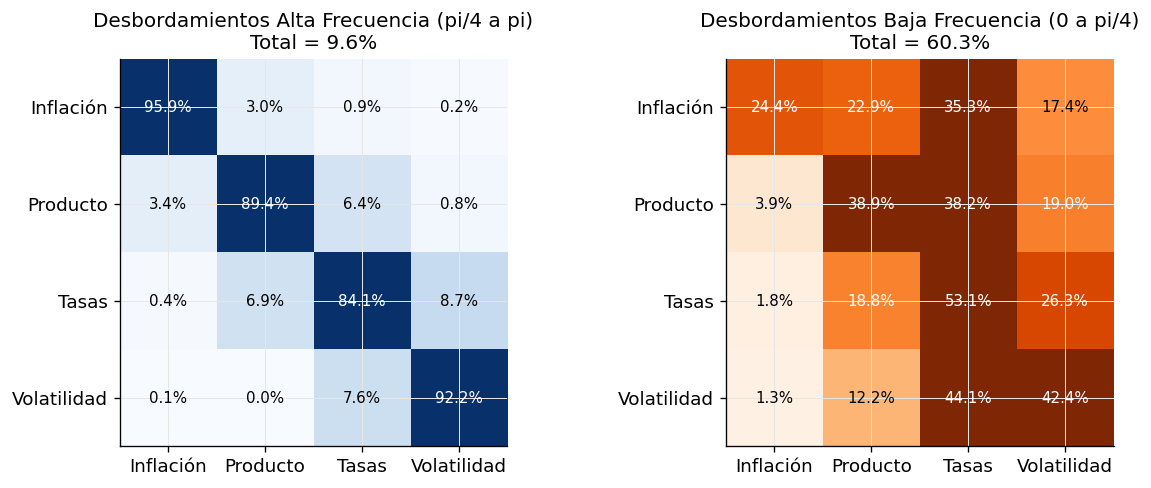

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

var_labels = ["Inflación", "Producto", "Tasas", "Volatilidad"]

# Panel Izquierdo: Desbordamientos Direccionales de Alta Frecuencia
im1 = ax1.imshow(band_mat_high * 100, cmap="Blues", vmin=0, vmax=35)
ax1.set_xticks(range(N)); ax1.set_yticks(range(N))
ax1.set_xticklabels(var_labels); ax1.set_yticklabels(var_labels)
ax1.set_title(f"Desbordamientos Alta Frecuencia (pi/4 a pi)\nTotal = {total_high:.1f}%")

for i in range(N):
    for j in range(N):
        ax1.text(j, i, f"{band_mat_high[i, j]*100:.1f}%",
                 ha="center", va="center", color="white" if band_mat_high[i, j]*100 > 18 else "black", fontsize=9)

# Panel Derecho: Desbordamientos Direccionales de Baja Frecuencia
im2 = ax2.imshow(band_mat_low * 100, cmap="Oranges", vmin=0, vmax=35)
ax2.set_xticks(range(N)); ax2.set_yticks(range(N))
ax2.set_xticklabels(var_labels); ax2.set_yticklabels(var_labels)
ax2.set_title(f"Desbordamientos Baja Frecuencia (0 a pi/4)\nTotal = {total_low:.1f}%")

for i in range(N):
    for j in range(N):
        ax2.text(j, i, f"{band_mat_low[i, j]*100:.1f}%",
                 ha="center", va="center", color="white" if band_mat_low[i, j]*100 > 18 else "black", fontsize=9)

plt.tight_layout()
plt.show()

**Leyendo el resultado.** La descomposición de frecuencias expone la estructura de transmisión: los desbordamientos de corto plazo están dominados por la volatilidad financiera y los ajustes de tasas de interés, mientras que los desbordamientos de baja frecuencia son impulsados por choques persistentes de inflación y brecha de producto. Los índices de desbordamiento de VAR tradicionales en el dominio del tiempo oscurecen esta dependencia del horizonte.

## Tu turno — transmisión de choques a alta frecuencia

**Ejercicios.**
1. *Básico*: Desplaza el límite de frecuencia de $\pi/4$ a $\pi/2$ (`# ← cambia esto ...`) para aislar ruido de ultra alta frecuencia.
2. *Intermedio*: Incrementa el número de rezagos del VAR a `var_lags=2`. Verifica que dinámicas de rezago más altas enriquecen la conectividad a baja frecuencia.
3. *Avanzado*: Compara las matrices de desbordamiento de frecuencia de Baruník-Křehlík a través de diferentes resoluciones de integración espectral.

In [3]:
# Bloque de código Tu turno
cutoff_yt = np.pi / 2.0  # ← cambia esto: prueba np.pi / 2.0 o np.pi / 3.0

res_yt = barunik_krehlik(data, var_lags=1, freq_bounds=(cutoff_yt, np.pi))
print(f"Nueva Frecuencia de Corte de Alta Frecuencia: {cutoff_yt:.3f} rad/periodo")
print(f"Total Desbordamiento Alta Frecuencia: {res_yt['total_spillover']:.2f}%")

# Afirmación válida para el valor por defecto
assert res_yt["total_spillover"] > 0.0, "El índice de desbordamiento debe ser positivo"

Nueva Frecuencia de Corte de Alta Frecuencia: 1.571 rad/periodo
Total Desbordamiento Alta Frecuencia: 6.74%


## ¿Qué tan exhaustivo es esto?

`puremacro.connectedness.bk2018` implementa los algoritmos espectrales de descomposición de varianza en el dominio de la frecuencia exactos de Baruník & Křehlík (2018). Se conecta con `puremacro.var` para estimación, funciones de impulso respuesta y descomposiciones de varianza del error de pronóstico.